# How to calculate the vorticity of a 2D field

**Step 1: Create FELiCSMesh, FELiCSSpace and Field**

We consider the domain $\Omega = (0,1) \times (0,1)$, and discretize with triangular elements. The 2D velocity field is a $P2$ finite element vector field and the magnitude of the vorticity has been stored in a $P2$ finite element scalar field. 

In [1]:
from FELiCS.SpaceDisc.FELiCSMesh import FELiCSMesh
from FELiCS.SpaceDisc.FEMSpaces  import create_function_space
from FELiCS.Fields.Field         import Field
from FELiCS.IO.Reader            import Reader

meshFileName = "./square_mesh.msh"
coordinateSystemName = "Cartesian"

# Create a FELiCS mesh from the gmsh file
mesh = FELiCSMesh(coordinateSystemName, meshFileName)

scalarSpace = create_function_space(mesh, degree=2, dim=1)
vectorSpace = create_function_space(mesh, degree=2, dim=2)

phiVec = Field(vectorSpace, mesh=mesh, name="function_2d")
phiVec.import_data(Reader(), "input")


(         (               (     
)\ )      ) )       (    )\ )  
(()/(  (  (()/( (    )\   (()/(  
/(_)) )\  /(_)))\  (((_)  /(_)) 
(_)_)((_) (_)) ((_) )\___ (_))   
| __|| __|| |   (_)((/ __|/ __|  
| _| | _| | |__ | | | (__ \__ \  
|_|  |___||____||_|  \___||___/  
Git commit: 


fatal: not a git repository: '/home/demange/anaconda3/envs/felics/lib/python3.13/site-packages/../.git'
Info     | FELiCSMesh.py          | __init__                   (line 124 ) : Opening mesh file: ./square_mesh.msh
Info     | FELiCSMesh.py          | __init__                   (line 132 ) : Mesh contains 513 nodes and 1024 elements
Info     | Reader.py              | _interpolate_to_calc_mesh  (line 706 ) : Linear interpolation took 0.2 seconds. (Mesh size: (1969, 2))


(<FELiCS.Fields.Field.Field at 0x75d08b5e0c20>, [])

**Step 2: Computing the vorticity and comparison with the analytical results.**

For a 2D velocity field given by $\vec{\textbf{u}} = (u, v)$, the vorticity $\omega$ is defined as

$$
    \omega = \nabla \times \vec{\textbf{u}} = (\frac{\partial u}{\partial y} - \frac{\partial v}{\partial x}) \hat{z},
$$

where $\hat{x}, \hat{y}, \hat{z}$, represent the unit vectors along the Cartesian coordinate axes in 3D space. However, for a 3D velocity field given by $\vec{\textbf{u}} = (u, v, w)$, the vorticity $\omega$ is defined as

$$
    \omega = \nabla \times \vec{\textbf{u}} = \left( \frac{\partial w}{\partial y} - \frac{\partial v}{\partial z} \right) \hat{x}
+
\left( \frac{\partial u}{\partial z} - \frac{\partial w}{\partial x} \right) \hat{y}
+
\left( \frac{\partial v}{\partial x} - \frac{\partial u}{\partial y} \right) \hat{z}
$$



<!-- We now want to calculate the gradient of our scalar quantity using the `getGradient()` method of our Field class. This method returns a Field.
To verify the solution we also calculate the gradient manually. -->

In [2]:
vorticity = phiVec.get_vorticity_field()

**Step3. Postprocessing via plotting contour plots**

We plot two 2D color plots of the velocity and vorticity magnitudes respectively.

<Axes: xlabel='x', ylabel='y'>

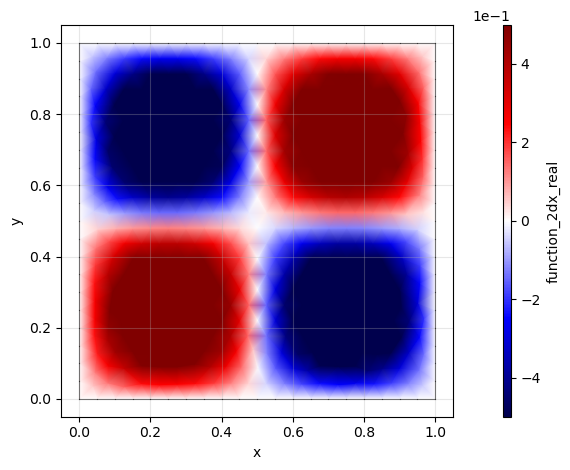

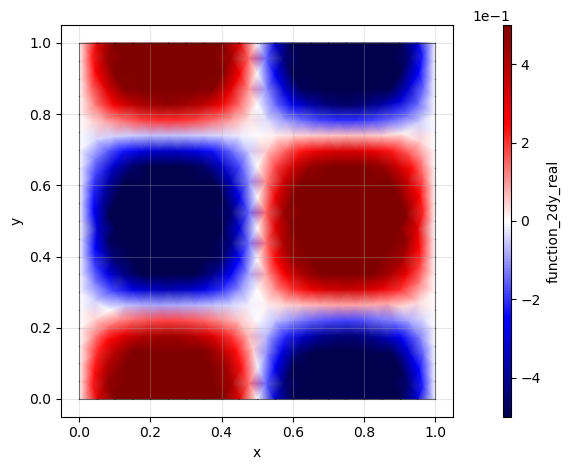

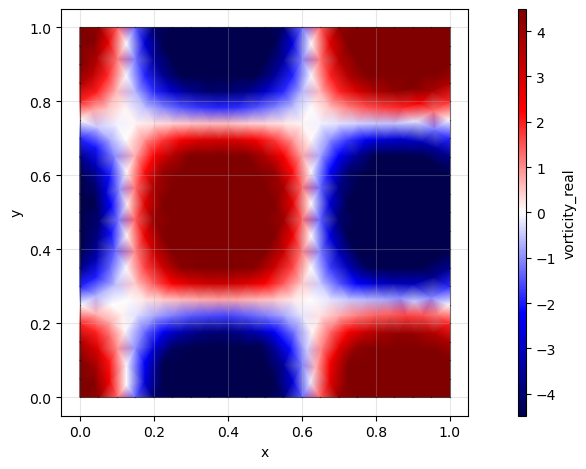

In [3]:
[phi_x, phi_y] = phiVec.get_list_of_sub_fields()

phi_x.plot()
phi_y.plot()
vorticity.plot()
